Data Cleaning 

In [ ]:
import pandas as pd 
import numpy as np
import os
os.chdir("...\\Machine Learning\\Project")

In [ ]:
df1= pd.read_csv('audi.csv')

In [ ]:
print(f"Shape: {df1.shape} (Samples: {df1.shape[0]}, Features: {df1.shape[1]})")

In [ ]:
print("Data Types")
print(df1.info())

In [ ]:
print("Statistical Summary")
print(df1.describe())

In [ ]:
duplicate_count = df1.duplicated().sum()
print(f"Detected Duplicates: {duplicate_count}")
if duplicate_count > 0:
    df1 = df1.drop_duplicates()
    print(f"Removed {duplicate_count} duplicate samples to prevent bias.")
else:
    print("No duplicates found.")

In [ ]:
zero_engine = df1[df1['engineSize'] == 0.0]
print(f"Detected 'Zero' Engine Sizes: {len(zero_engine)}")

if len(zero_engine) > 0:
    df1 = df1[df1['engineSize'] > 0.0]
    print(f"Removed {len(zero_engine)} samples as entry errors.")

In [ ]:
zero_tax = df1[df1['tax'] == 0]
print(f"Detected 'Zero' Tax: {len(zero_tax)}")
print("Retained samples (Valid for low-emission vehicles).")

In [ ]:
null_counts = df1.isnull().sum().sum()
print(f"Missing Values: {null_counts}")

In [ ]:
print(f"CLEANING COMPLETE")
print(f"Final Matrix Shape: {df1.shape}")

df1.to_csv('audiCleaned.csv', index=False)

In [ ]:
df= pd.read_csv("vehicles.csv")
df.head()

In [ ]:
print(f"Original shape: {df.shape}")

print(df.isnull().mean() * 100)

In [ ]:
features=[
    'price', 'year', 'odometer',          
    'cylinders', 'condition',           
    'manufacturer', 'fuel',     
    'drive', 'model'
]
df=df[features]

In [ ]:
df = df.dropna(subset=['manufacturer', 'model', 'year'])

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

In [ ]:
df['condition'] = df['condition'].fillna('unknown')
df['cylinders'] = df['cylinders'].fillna('unknown')
df['fuel'] = df['fuel'].fillna('unknown')
df['drive'] = df['drive'].fillna('unknown')

In [ ]:
df = df[(df['price'] > 500) & (df['price'] < 100000)]
df = df[(df['year'] > 1990)]
df = df[(df['odometer'] < 300000)]

print(f"New Final Count: {len(df)}")

In [ ]:
currYear=2025
df['age']= currYear-df['year']
df=df[df['age']>0]
print(df[['year', 'age']].head())

In [ ]:
def get_region(manufacturer):
    
    if pd.isna(manufacturer):
        return 'unknown'
        
    m = str(manufacturer).lower().strip()
    
    usa = [
        'ford', 'chevrolet', 'chevy', 'dodge', 'jeep', 'ram', 'gmc', 
        'buick', 'cadillac', 'chrysler', 'lincoln', 'pontiac', 'saturn', 
        'mercury', 'tesla', 'harley-davidson'
    ]
    japan = [
        'toyota', 'honda', 'nissan', 'subaru', 'mazda', 'mitsubishi', 
        'lexus', 'infiniti', 'acura', 'datsun'
    ]
    germany = [
        'bmw', 'mercedes-benz', 'audi', 'volkswagen', 'porsche'
    ]
    korea = [
        'hyundai', 'kia'
    ]
    europe_other = [
        'land rover', 'jaguar', 'volvo', 'fiat', 'alfa-romeo', 
        'ferrari', 'aston-martin', 'rover', 'mini', 'morgan'
    ]
    
    if m in usa:
        return 'USA'
    elif m in japan:
        return 'Japan'
    elif m in germany:
        return 'Germany'
    elif m in korea:
        return 'Korea'
    elif m in europe_other:
        return 'Europe'
    else:
        return 'Other'


df['manufacturerRegion'] = df['manufacturer'].apply(get_region)

print(df['manufacturerRegion'].value_counts())

In [ ]:
condition_map = {
    'salvage': 0,
    'fair': 1,
    'good': 2,
    'excellent': 3,
    'like new': 4,
    'new': 5
}
df['conditionRank'] = df['condition'].map(condition_map)
df['conditionRank'] = df['conditionRank'].fillna(2).astype(int)

In [ ]:
df['conditionRank'].unique()

In [ ]:
def clean_cylinders(x):
    if pd.isna(x) or str(x).lower() == 'other':
        return 4
    
    try:
        return int(str(x).split()[0])
    except:
        return 4 

In [ ]:
df['cylindersNum']=df['cylinders'].apply(clean_cylinders)
print (df['conditionRank'].value_counts().sort_index())
print (df['cylindersNum'].value_counts())

In [ ]:
df.info()

In [ ]:
model_counts = df['model'].value_counts()
df['model_freq'] = df['model'].map(model_counts)
df_clean = df.drop(columns=['cylinders', 'condition', 'model', 'year'])

In [ ]:
print("Columns ready for splitting:")
print(df_clean.columns.tolist())
print("\nFirst 5 rows:")
print(df_clean.head())

In [ ]:
df.to_csv('vehiclesCleaned.csv')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='red')
plt.title('Raw Price Distribution (Right-Skewed)')
plt.xlabel('Price ($)')
plt.ylabel('Count')

In [ ]:
df['price_log'] = np.log1p(df['price'])

In [ ]:
plt.subplot(1, 2, 2)
sns.histplot(df['price_log'], bins=50, kde=True, color='green')
plt.title('Log-Transformed Price (Normalized)')
plt.xlabel('Log(Price)')
plt.ylabel('Count')

In [ ]:
print(f"Skewness before log transform: {df['price'].skew():.2f}")
print(f"Skewness after log transform:  {df['price_log'].skew():.2f}")

In [ ]:
df_clean = pd.read_csv(r'....\Machine Learning\Project\vehiclesCleaned.csv')

cols_to_drop = [
    'model',
    'cylinders',
    'condition',
    'Unnamed: 0'
]

In [ ]:
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error

In [4]:
os.chdir("....\\Machine Learning\\Project")
df_audi = pd.read_csv('audiCleaned.csv')

In [6]:
print(f"Audi Data Loaded. Shape: {df_audi.shape}")

Audi Data Loaded. Shape: (10513, 9)


In [8]:
X = df_audi.drop('price', axis=1)
y = np.log1p(df_audi['price'])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [14]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

In [16]:
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [18]:
print(f"Encoding Complete. Features: {X_train_encoded.shape[1]}")

Encoding Complete. Features: 37


Training

In [21]:
def evaluateAudi(model, name):
    preds_log = model.predict(X_test_encoded)
    preds_real = np.expm1(preds_log)
    actual_real = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(actual_real, preds_real))
    r2 = r2_score(actual_real, preds_real)
    mae = mean_absolute_error(actual_real, preds_real)
    


    print(f"\n--- {name} Results ---")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: ${mae:.2f}")
    return r2
    

In [23]:
svr = SVR(kernel='rbf', C=1, epsilon=0.1)
svr.fit(X_train_encoded, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [24]:
r2_svr = evaluateAudi(svr, "SVR (RBF)")


--- SVR (RBF) Results ---
RMSE: $2,855.44
R2 Score: 0.9453
MAE: $1776.87


In [27]:
sgd = SGDRegressor(loss='epsilon_insensitive', max_iter=1000, random_state=42)
sgd.fit(X_train_encoded, y_train)

,loss,'epsilon_insensitive'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [29]:
r2_sgd= evaluateAudi(sgd, "Linear SGD-SVR")


--- Linear SGD-SVR Results ---
RMSE: $4,740.04
R2 Score: 0.8492
MAE: $2547.57


In [31]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_encoded, y_train)
r2_rf = evaluateAudi(rf, "Random Forest")


--- Random Forest Results ---
RMSE: $2,521.38
R2 Score: 0.9573
MAE: $1633.13


In [33]:
rf_opt = RandomForestRegressor(
    n_estimators=200, 
    min_samples_leaf=2,
    max_features='sqrt', # Good for high-dimensional data (60+ cols)
    random_state=42, 
    n_jobs=-1
)

In [35]:
rf_opt.fit(X_train_encoded, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
preds_log_opt = rf_opt.predict(X_test_encoded)
preds_real_opt = np.expm1(preds_log_opt)
actual_real = np.expm1(y_test)

In [39]:
r2_rf = evaluateAudi(rf_opt, "Random Forest Optimized")


--- Random Forest Optimized Results ---
RMSE: $3,151.01
R2 Score: 0.9333
MAE: $1720.98


C:\Users\ASUS\AppData\Local\Temp\ipykernel_77336\1618402419.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['SVR (RBF)', 'Random Forest'], y=[r2_svr, r2_rf], palette='magma')


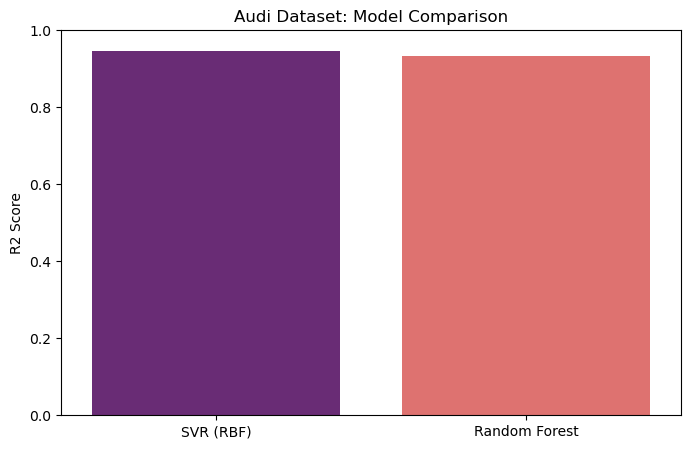

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(x=['SVR (RBF)', 'Random Forest'], y=[r2_svr, r2_rf], palette='magma')
plt.title("Audi Dataset: Model Comparison")
plt.ylabel("R2 Score")
plt.ylim(0, 1)
plt.show()

In [43]:
df_vehicles = pd.read_csv('vehiclesCleaned.csv')

cols_to_drop = [
    'model',
    'cylinders',
    'condition',
    'Unnamed: 0'
]

In [45]:
df_vehicles = df_vehicles.drop(columns=cols_to_drop, errors='ignore')

In [47]:
X = df_vehicles.drop('price', axis=1)
y = np.log1p(df_vehicles['price'])

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [53]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

In [55]:
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Encoding Complete. Final Features: {X_train_encoded.shape[1]}")

Encoding Complete. Final Features: 61


In [57]:
def evaluateVehicles(model, name):
    preds_log = model.predict(X_test_encoded)
    #cconvert
    preds_real = np.expm1(preds_log)
    actual_real = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(actual_real, preds_real))
    r2 = r2_score(actual_real, preds_real)
    mae = mean_absolute_error(actual_real, preds_real)

    print(f"--- {name} Results ---")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: ${mae:.2f}")

    return r2, preds_real, actual_real

In [59]:
sgd = SGDRegressor(loss='epsilon_insensitive', max_iter=1000, random_state=42)
sgd.fit(X_train_encoded, y_train)

,loss,'epsilon_insensitive'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [61]:
r2_sgd, preds_sgd, y_true = evaluateVehicles(sgd, "Linear SGD-SVR")

--- Linear SGD-SVR Results ---
RMSE: $8,316.15
R2 Score: 0.6533
MAE: $5196.84


In [63]:
rf = RandomForestRegressor(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_encoded, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
r2_rf, preds_rf, _ = evaluateVehicles(rf, "Random Forest")

--- Random Forest Results ---
RMSE: $5,437.78
R2 Score: 0.8518
MAE: $2932.81


In [69]:
rf_opt = RandomForestRegressor(
    n_estimators=200, 
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42, 
    n_jobs=-1
)

In [71]:
rf_opt.fit(X_train_encoded, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
r2_rf_opt, preds_rf_opt, y_true = evaluateVehicles(rf_opt, "Random Forest Optimized")

--- Random Forest Optimized Results ---
RMSE: $5,125.53
R2 Score: 0.8683
MAE: $2708.33


C:\Users\ASUS\AppData\Local\Temp\ipykernel_51284\1956388110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Linear SGD', 'Random Forest'], y=[r2_sgd, r2_rf], palette='viridis')


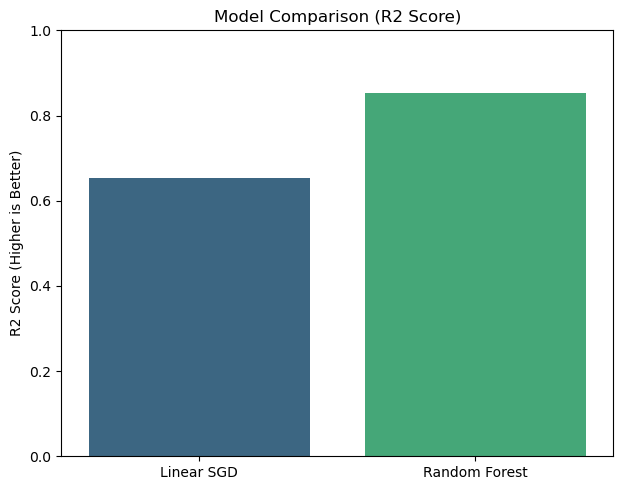

In [187]:
plt.figure(figsize=(12, 5))

# Plot R2 Comparison
plt.subplot(1, 2, 1)
sns.barplot(x=['Linear SGD', 'Random Forest'], y=[r2_sgd, r2_rf], palette='viridis')
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score (Higher is Better)")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

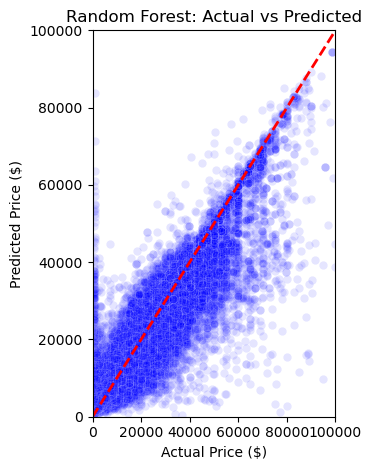

In [189]:
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_true, y=preds_rf, alpha=0.1, color='blue')
plt.plot([0, 100000], [0, 100000], '--r', linewidth=2) # Perfect fit line
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.xlim(0, 100000)
plt.ylim(0, 100000)

plt.tight_layout()
plt.show()

In [75]:
gbr = GradientBoostingRegressor(
    n_estimators=500, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42,
    verbose=1
)

In [77]:
gbr.fit(X_train_encoded, y_train)

      Iter       Train Loss   Remaining Time 
         1           0.6675           19.33m
         2           0.5944           19.52m
         3           0.5349           19.46m
         4           0.4859           19.03m
         5           0.4454           18.34m
         6           0.4119           18.32m
         7           0.3839           18.48m
         8           0.3599           18.53m
         9           0.3407           18.62m
        10           0.3238           18.69m
        20           0.2462           17.64m
        30           0.2237           17.39m
        40           0.2139           16.94m
        50           0.2079           16.51m
        60           0.2036           16.34m
        70           0.1999           15.93m
        80           0.1968           15.40m
        90           0.1944           15.05m
       100           0.1923           14.62m
       200           0.1735           10.57m
       300           0.1589            6.96m
       40

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


In [79]:
r2_gbr, preds_gbr, y_true = evaluateVehicles(gbr, "Random Forest Optimized")

--- Random Forest Optimized Results ---
RMSE: $5,898.38
R2 Score: 0.8256
MAE: $3506.54


C:\Users\ASUS\AppData\Local\Temp\ipykernel_51284\3392537805.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


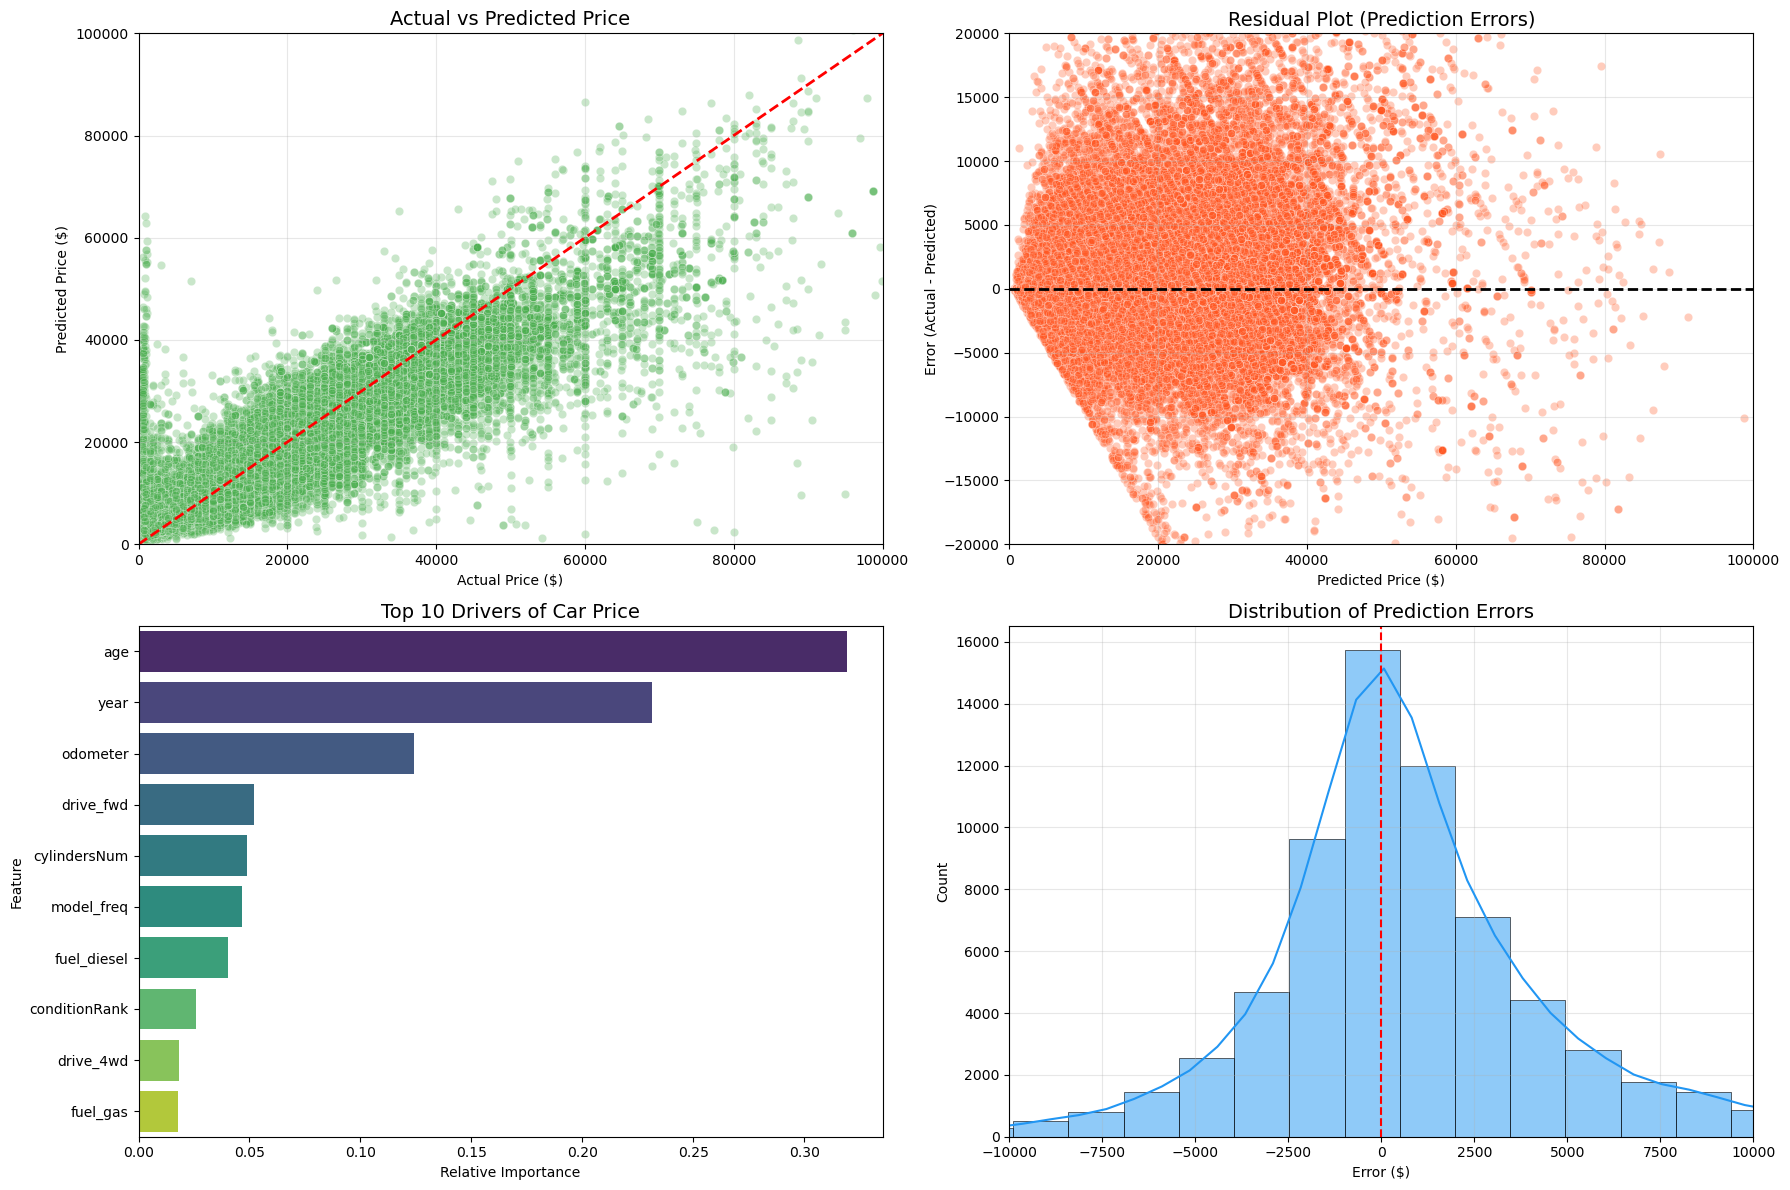

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# ADVANCED VISUALIZATION SUITE
# ==========================================
# Run this AFTER training your best model (e.g., 'gbr' or 'rf')
# Assumes you have: gbr (model), X_test_encoded, y_test (log scale)

# 1. Get Predictions
preds_log = gbr.predict(X_test_encoded)
preds_real = np.expm1(preds_log)
actual_real = np.expm1(y_test)
residuals = actual_real - preds_real

plt.figure(figsize=(18, 12))

# --- PLOT 1: Actual vs Predicted (The Standard Check) ---
plt.subplot(2, 2, 1)
sns.scatterplot(x=actual_real, y=preds_real, alpha=0.3, color='#4CAF50')
plt.plot([0, 100000], [0, 100000], '--r', linewidth=2) # Perfect fit line
plt.title('Actual vs Predicted Price', fontsize=14)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.xlim(0, 100000)
plt.ylim(0, 100000)
plt.grid(True, alpha=0.3)

# --- PLOT 2: Residual Plot (Error Analysis) ---
plt.subplot(2, 2, 2)
sns.scatterplot(x=preds_real, y=residuals, alpha=0.3, color='#FF5722')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Residual Plot (Prediction Errors)', fontsize=14)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Error (Actual - Predicted)')
plt.xlim(0, 100000)
plt.ylim(-20000, 20000) # Zoom in to see the error spread
plt.grid(True, alpha=0.3)

# --- PLOT 3: Feature Importance (The Scientific Proof) ---
plt.subplot(2, 2, 3)
# Get feature importance from the model
importances = gbr.feature_importances_
feature_names = X_test_encoded.columns
# Create a DataFrame to sort them
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_features = feature_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 10 Drivers of Car Price', fontsize=14)
plt.xlabel('Relative Importance')

# --- PLOT 4: Error Distribution (Bias Check) ---
plt.subplot(2, 2, 4)
sns.histplot(residuals, bins=100, kde=True, color='#2196F3')
plt.axvline(0, color='r', linestyle='--')
plt.title('Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Error ($)')
plt.xlim(-10000, 10000) # Zoom in on the center
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()